# INF8775 – Analyse et conception d’algorithmes
# TP1 – Automne 2026

NOM, Prénom, 1234567

NOM, Prénom, 1234567

Note finale:

<u>**Date limite de remise :**</u>  5 octobre 23h59 (Groupe 1), 6 octobre 23h59 (Groupe 2)

# Instructions

## Rédaction et remise du rapport

- Ce notebook constitue à la fois le sujet du TP, votre code et votre rapport. Il contient déjà du code pour faciliter vos mesures et l'affichage de vos résultats, ainsi qu'un squelette pour votre rapport.

- Complétez directement le notebook, vous êtes libres de créer des nouvelles cellules de code ou de texte.

- Les questions et tâches à effectuer sont généralement indiquées par un TODO, mais lisez attentivement car nous pourrions avoir oublié d'en indiquer certaines.

- Des questions sont réutilisées d'un algorithme à l'autre (puisque l'on reproduit les expérimentations à des fins de comparaison). Veillez à suffisamment développer les premières réponses afin que l'on comprenne bien votre raisonnement et pour montrer votre bonne compréhension. Vous pourrez être plus concis par la suite.

- <u>**IMPORTANT**</u> Remettez le fichier du notebook sur Moodle avec le nom `MATRICULE1_MATRICULE2.ipynb`

- Vous pouvez inclure du code trouvé sur Internet, mais vous devez en mentionner la source, sous peine d'être sanctionnés pour plagiat. Cela s'applique aussi au niveau de l'utilisation d'IA pour générer du code. Par contre, veuillez ne pas utiliser d'IA pour rédiger vos analyses, sous peine d'être pénalisé.

## Mise en situation

Ce travail pratique se répartit sur deux séances de laboratoire et porte sur l’analyse empirique et hybride des algorithmes. Dans les capsules vidéo de la semaine 3, trois approches d’analyse de l’implantation d’un algorithme sont décrites. Vous les mettrez en pratique pour des algorithmes de résolution d’un problème connu.


## Description du problème

On vous demande de résoudre le problème classique de trier une liste de nombres donnés.

La taille de la liste changera d'un échantillon à l'autre. Vous pouvez utiliser le code fourni pour générer des exemplaires.

## Algorithmes à implanter

On vous demande de résoudre ce problème de 5 façons différentes :

1. En utilisant un algorithme naif: `Selection Sort` ;
2. En utilisant une amélioration de l'algorithme précédent: `Bidirectional Selection Sort` ;
3. En utilisant un algorithme de type diviser pour régner: `Quick Sort` ;
4. En utilisant l'algorithme précédent avec un seuil de récursivité non trivial ;

Pour les algorithmes 3 et 4, vous devrez évaluer séparément les deux stratégies de sélection du pivot suivantes: sélectionner le premier élément et sélectionner un élément aléatoirement.

Pour l’algorithme 4, vous devrez déterminer un seuil de récursivité expérimentalement. Les exemplaires dont la taille est inférieure à ce seuil ne sont plus résolus récursivement mais plutôt directement avec l’algorithme 2.



## Jeu de données

La classe Problem existe pour simplifier l'interface des différentes fonctions utilitaires. Elle permet de générer des jeux de données avec la méthode `generate_sample` ci-dessous. Elle génère une liste d'une taille donnée contenant des nombres entre 1 et 10 000. Vous pouvez utilisez des listes aléatoires pour tester votre code.

In [ ]:
import random
from collections.abc import Iterable
from enum import Enum

class InstanceDist(Enum):
    RANDOM = 1
    SORTED = 2

class Problem():
    def __init__(self, size: int, num_samples: int = 5, distribution: InstanceDist = InstanceDist.RANDOM) -> None:
        self.size = size
        self.num_samples = num_samples
        self.distribution = distribution

    def generate_sample(self) -> list[int]:
        """Returns a list of the given size """
        sample = [random.randint(1, 10000) for _ in range(self.size)]

        if self.distribution == InstanceDist.SORTED:
            sample.sort()
            
        return sample

    def generate_dataset(self) -> Iterable[list[int]]:
        """Returns an iterator over as many samples as are described """
        return (self.generate_sample() for _ in range(self.num_samples))

# Implantations et expérimentations

Ces fonctions auxiliaires vous sont fournies pour vérifier l'exactitude des vos algorithmes, mesurer leur performance et afficher vos résultats.

Il est recommandé de prendre le temps de lire et comprendre le code.

Exécutez la cellule ci-dessous pour pouvoir utiliser les fonctions auxiliaires.

In [ ]:
import matplotlib.pyplot as plt
import time
from collections.abc import Callable
from math import log10
from scipy.stats import linregress

class InvalidSolution(Exception):
    def __init__(self):
        super().__init__("Invalid solution, verify your code.")

class Measure():
    """A wrapper to contain information on taken measures"""
    def __init__(self, size: int, mean: int) -> None:
        self.size = size
        self.mean = mean

def convert_list_to_dict(original: list[int]) -> dict[int:int]:
    """Converts a list into a dictionary of frequencies"""
    freq: dict[int:int] = dict()
    for iter in original:
        if iter not in freq.keys():
            freq[iter] = 0
        freq[iter] += 1
    return freq

def is_valid_solution(original: list[int], solution: list[int]) -> bool:
    """Validates both if the solution is sorted and if the list was not modified"""
    # Lists must be of equal length
    if len(solution) != len(original):
        return False

    # List must be in increasing order
    for i in range(1, len(solution)):
        if solution[i-1] > solution[i]:
            return False

    original_freq = convert_list_to_dict(original)
    solution_freq = convert_list_to_dict(solution)
    # Lists must have the same values
    for key in original_freq.keys():
        if key not in solution_freq.keys() or\
            solution_freq[key] != original_freq[key]:
            return False

    # Solution is valid
    return True

def make_problems(sizes: list[int], num_samples: int = 5, distribution: InstanceDist = InstanceDist.RANDOM) -> list[Problem]:
    """Creates problem instances using given sizes"""
    problems: list[Problem] = []
    for size in sizes:
        problems.append(Problem(size,num_samples,distribution))
    return problems

def measure(procedure: Callable[[list[int]],list[int]], sample: list[int], time_scale: int = 1000) -> int:
    """Returns the time in milliseconds taken to run the procedure.

    Raises:
        InvalidSolution: If the procedure returns an invalid solution, raises an exception.
    """
    start: int = time.time() * time_scale
    solution: list[int] = procedure(sample)
    end: int = time.time() * time_scale
    if not is_valid_solution(sample, solution):
        raise InvalidSolution()
    return round(end - start)

def measure_mean(procedure: Callable[[list[int]],list[int]], prob: Problem, time_scale: int = 1000) -> Measure:
    """Generates multiple samples with the specified parameters and returns the mean time in milliseconds

    Raises:
        InvalidSolution: If one of the samples results in an invalid solution.
    """
    mean_time = sum(
        [measure(procedure,sample,time_scale) for sample in prob.generate_dataset()]
    ) / prob.num_samples
    return Measure(prob.size, mean_time)

def measure_range(procedure: Callable[[list[int]],list[int]], problems: list[Problem], time_scale: int = 1000) -> list[Measure]:
    """Measures the mean time taken in milliseconds for each size in the given list.
    Raises:
        InvalidSolution: If one of the samples results in an invalid solution.

    Returns:
        A list of Measure instances containing the specifications
        of the problem as well as the mean time.
    """
    return [
        measure_mean(procedure, prob, time_scale)
        for prob in problems
    ]

def test_threshold(
    procedure: Callable[[list[int],int],list[int]],
    thresholds: list[int], problem: Problem, time_scale: int = 1000
) -> dict[int,int]:
    """Tests the different thresholds on the same problem instance."""
    threshold_measures = {t:0 for t in thresholds}
    for sample in problem.generate_dataset():
        for t in thresholds:
            original = sample.copy()
            start = time.time() * time_scale
            solution = procedure(original,t)
            end = time.time() * time_scale
            if not is_valid_solution(sample,solution):
                raise InvalidSolution()
            threshold_measures[t] += (end - start) / problem.num_samples
    return threshold_measures

def estimate_threshold(
    first_data: dict[int,int],
    second_data: dict[int,int],
    first_label: str,
    second_label: str,
    y_label: str
):
    plt.plot(list(first_data.keys()),list(first_data.values()),label=first_label)
    plt.plot(list(second_data.keys()),list(second_data.values()),label=second_label)
    plt.xlabel('Taille')
    plt.ylabel(y_label)
    plt.title('Estimation du seuil')
    plt.legend()
    plt.show()

def display_threshold_measures(data: dict[int,int]):
    """Displays a graph of the time take to solve in regards to the chosen threshold"""
    x = list(data.keys())
    y = list(data.values())
    plt.plot(x, y, label='Mesures')
    plt.scatter(x, y, label='Mesures')

    # Add labels and title
    plt.xlabel('Seuil')
    plt.ylabel('Temps (ms)')
    plt.title('Selection du seuil')
    plt.show()

def display_data_as_table(measures: list[Measure]):
    """Prints a table with the data in the given list of measures"""
    print("{: <12} {: <12}".format("Taille", "Temps moyen (ms)"))
    for measure in measures:
        print("{: <12} {: <12}".format(measure.size, measure.mean))

### The different tests are below, the names are in french to avoid confusion

def test_de_puissance(
    data: dict[int,int],
    x_label: str,
    y_label: str,
    title: str = "Test de puissance"
):
    """Takes the data and displays it into the corresponding test graph.
    It applies no transformations to the data.

    Args:
        data (dict[int,int]): A dictionnary mapping the x variable to the y variable
    """
    # Log both sets of values
    x = list(data.keys())
    y = list(data.values())

    # Perform the lin regression
    m, b, rvalue, _, _ = linregress(x, y)

    # Estimate the values of y based on the lin regression results
    predicted = [m * iter + b for iter in x]

    # Create the line equation
    line_eq = f"y = {m:.2f}x + {b:.2f}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, predicted, color="red", label=f'Regression linéaire R²={round(rvalue**2,6)}')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()

def test_de_rapport(
    data: dict[int,int],
    x_label: str,
    y_label: str,
    title: str = "Test de rapport"
):
    """Takes the data and displays it into the corresponding test graph.
    It applies no transformations to the data.

    Args:
        data (dict[int,int]): A dictionnary mapping the x variable to the y variable
    """
    x = list(data.keys())
    y = list(data.values())

    plt.plot(x, y, label='Mesures')
    plt.scatter(x, y, label='Mesures')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()

def test_de_constantes(
    data: dict[int,int],
    x_label: str,
    y_label: str = "Temps (ms)",
    title: str = "Test de constantes"
):
    """Takes the data and displays it into the corresponding test graph.
    It applies no transformations to the data.

    Args:
        data (dict[int,int]): A dictionnary mapping the x variable to the y variable
    """
    x = list(data.keys())
    y = list(data.values())

    # Perform linear regression
    m, b, rvalue, _, _ = linregress(x, y)

    predicted = [m * iter + b for iter in x]

    # Create the line equation
    line_eq = f"y = {m:.2E}x + {b:.2E}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, predicted, color="red", label=f'Regression linéaire R²={round(rvalue**2,6)}')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()

## Partie 1 : Algorithme simple (Selection Sort) (5 pts)

### Implantation

<u>**Question 1.a):**</u> Implantez l'algorithme de tri Selection sort.

Utilisez la fonction `is_valid_solution` pour valider votre réponse sur quelques exemplaires aléatoires.

In [ ]:
def selection_sort(original: list[int]) -> list[int]:    
    n = len(original)
    for i in range(0, n):
        min_val = original[i]
        min_index = i
        for j in range(i+1, n):
            if original[j] < min_val:
                min_val = original[j]
                min_index = j
        temp = original[i]
        original[i] = min_val
        original[min_index] = temp
            
    return original

problem = Problem(10, 20)
testing_arrays = list(problem.generate_dataset())
valid_count = 0

for original_arr in testing_arrays:
    sorted_arr = selection_sort(original_arr)
    is_valid = is_valid_solution(original_arr, sorted_arr)
    if is_valid:
        valid_count += 1

print(f"Among {len(testing_arrays)} generated items for testing, {valid_count} are correctly sorted, {len(testing_arrays) - valid_count} are incorrectly sorted")


Among 20 generated items for testing, 20 are correctly sorted, 0 are incorrectly sorted


<u>**Question 1.b):**</u> Quelle est la complexité asymptotique théorique de cet algorithme? Veuillez justifier.

La complexite de cet algorithme est de l'ordre de O(n^2) dans le pire des cas avec n etant la taille du tableau original.

Justification:
La premiere boucle sera executee n fois dans le pire des cas, les 2 premieres affections et les 3 dernieres sont des operations elementaires de l'ordre O(1), tandis que la 2e boucle effectuera au plus n-1 operations a la premiere iteration, puis n-2, n-3 jusqu'a 1.

Le nombre d'operations de la deuxieme boucle est de (n-1) + (n-2) + ... + 2 + 1 = n(n-1)/2 = (n^2 - n)/2 qui est de l'ordre n^2

### Mesures

Pour cet algorithme ainsi que les prochains, vous devez choisir les différentes tailles de liste que vous voulez tester. Choisissez des tailles qui ont des résultats intéressants, une taille de 5 qui se termine en une fraction de millisecondes n'est pas le meilleur résultat pour faire des comparaisons.

Pour faire des mesures, utilisez la fonction `measure_range`. Elle permet de faire des mesures sur une liste de problèmes. Vous pouvez facilement créer des problèmes en utilisant la fonction `make_problems`. Le code fournit s'occupera de générer des échantillons aléatoires, de calculer le temps moyen et de vous retourner une liste de mesures. Vous pouvez utilisez la fonction `range` de python pour obtenir une grande liste et avoir plusieurs points (faites attention au temps d'exécution).

Ces données peuvent ensuite être passées aux fonctions `test_de_...` en les mettant dans un `dict` python tel que `x:y`. Les tests ont de la documentation pour expliquer leur utilisation en plus de détails.

<u>**Question 1.c):**</u> Faites afficher vos mesures dans un tableau avec la fonction `display_data_as_table`.

In [ ]:
selection_sort_problems = make_problems([x for x in range(1, 1000, 10)], 50)
selection_sort_measures = measure_range(selection_sort, problems=selection_sort_problems, time_scale=2000)

In [ ]:
display_data_as_table(measures=selection_sort_measures)

Taille       Temps moyen (ms)
1            0.0         
11           0.0         
21           0.04        
31           0.12        
41           0.28        
51           0.36        
61           0.2         
71           0.12        
81           0.72        
91           0.84        
101          0.72        
111          0.64        
121          0.92        
131          1.14        
141          1.84        
151          1.82        
161          1.44        
171          1.72        
181          2.98        
191          3.82        
201          3.18        
211          3.36        
221          3.98        
231          4.68        
241          6.68        
251          5.06        
261          3.98        
271          4.82        
281          6.04        
291          8.7         
301          8.66        
311          8.72        
321          9.26        
331          9.2         
341          10.62       
351          11.14       
361          11.42       
371     

### Analyse Hybride

*Veuillez faire attention à analyser correctement les graphiques générés, quitte à en ajouter d’autres, plutôt que d’interpréter uniquement ce à quoi vous vous attendiez.*




#### Test de puissance

<u>**Question 2.a):**</u> Effectuez le test de puissance de votre algorithme.

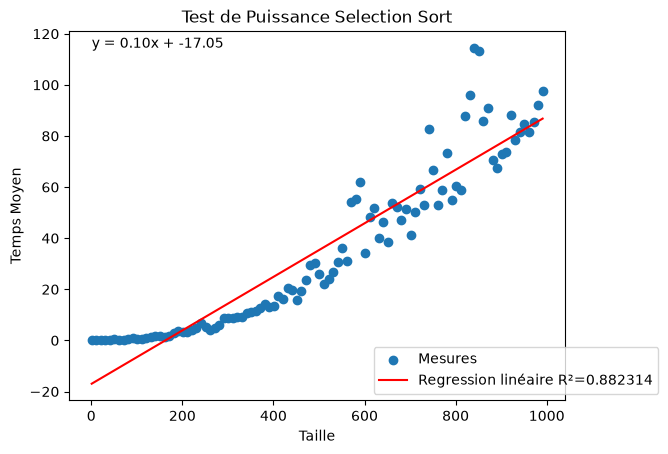

In [ ]:
data = {}
for m in selection_sort_measures:
  data[m.size] = m.mean
test_de_puissance(data=data, x_label='Taille', y_label='Temps Moyen', title="Test de Puissance Selection Sort")

<u>**Question 2.b):**</u> Analysez le graphe obtenu pour le test de puissance.

#### Test de rapport

<u>**Question 3.a):**</u> Effectuez le test de rapport de votre algorithme.

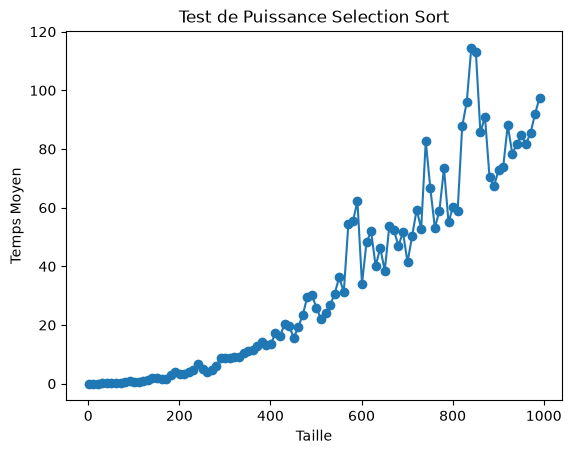

In [ ]:
data = {}
for m in selection_sort_measures:
  data[m.size] = m.mean
test_de_rapport(data=data, x_label='Taille', y_label='Temps Moyen', title="Test de Puissance Selection Sort")

<u>**Question 3.b):**</u> Analysez le graphe obtenu pour le test de rapport.

#### Test des constantes

<u>**Question 4.a):**</u> Effectuez le test des constantes de votre algorithme.

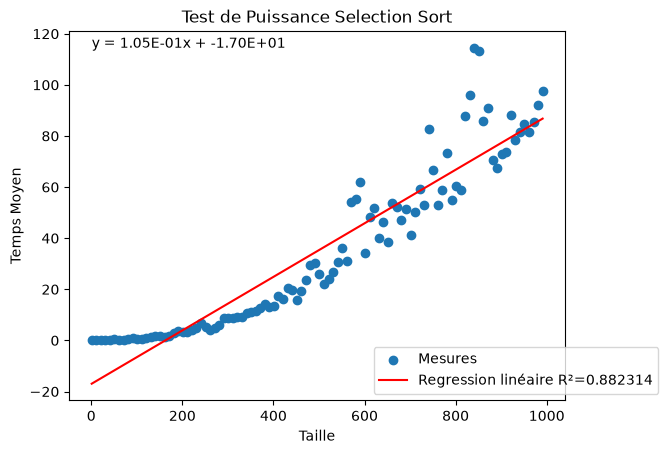

In [ ]:
data = {}
for m in selection_sort_measures:
  data[m.size] = m.mean
test_de_constantes(data=data, x_label='Taille', y_label='Temps Moyen', title="Test de Puissance Selection Sort")

<u>**Question 4.b):**</u> Analysez le graphe obtenu pour le test des constantes.

## Partie 2 : Algorithme amélioré (Bidirectional Selection Sort) (5 pts)

### Implantation

<u>**Question 1.a):**</u> Implantez l'algorithme de tri Bidirectional Selection sort.

Utilisez la fonction `is_valid_solution` pour valider votre réponse sur quelques exemplaires aléatoires.

In [ ]:
def bidirectional_selection_sort(original: list[int]) -> list[int]:
    n = len(original)
    left = 0
    right = n - 1
    
    while left < right:
        min_index = left
        max_index = right
        
        for i in range(left, right + 1):
            if original[i] < original[min_index]:
                min_index = i
            
            if original[i] > original[max_index]:
                max_index = i
    
        # swap value at left index with minimum value of the sorted array
        temp = original[left]
        original[left] = original[min_index]
        original[min_index] = temp
        
        # Dans certain cas, la valeur de max_index a ete permute ci-haut, donc remplacer le max_index par le min_index
        if left == max_index:
            max_index = min_index
        
        
        # swap value at right index with maximum value of the sorted array
        temp = original[right]
        original[right] = original[max_index]
        original[max_index] = temp
        
        left += 1
        right -= 1
                
    return original

problem = Problem(10, 20)
testing_arrays = list(problem.generate_dataset())
valid_count = 0

for original_arr in testing_arrays:
    original_copy = [*original_arr]
    sorted_arr = bidirectional_selection_sort(original_arr)
    is_valid = is_valid_solution(original_copy, sorted_arr)
    if is_valid:
        valid_count += 1

print(f"Among {len(testing_arrays)} generated items for testing, {valid_count} are correctly sorted {len(testing_arrays) - valid_count} are incorrectly sorted")


Among 20 generated items for testing, 20 are correctly sorted 0 are incorrectly sorted


<u>**Question 1.b):**</u> Quelle est la complexité asymptotique théorique de cet algorithme? Veuillez justifier.

La complexité de cet algorithme est de O(n²). La boucle while s'exécute environ n/2 fois, puisque left et right sont mis à jour d'une unité à chaque itération. À chaque itération, la boucle interne for, parcourt la fenetre [left, right] dont la taille diminue de 2 a chaque tour, soit (n-2), (n-4), (n-6) jusqu'a 1 ou 2.

La somme totale du nombre d'itérations etant obtenue a l'aide de la formule Somme de i allant de 1 a m (où m est sensiblement égal à n/2), des (n - 2i), nous donne un nombre d'itérations de l'ordre de n²/4, avec une constance multiplicative deux fois inférieure à celle du sélection sort classique.

La complexité de cet algorithme est donc de O(n²).

### Mesures

<u>**Question 1.c):**</u> Faites afficher vos mesures dans un tableau avec la fonction `display_data_as_table`.

In [ ]:
bi_directional_problems = make_problems([x for x in range(1, 1000, 10)], 50)
bi_directional_measures = measure_range(procedure=bidirectional_selection_sort, problems=bi_directional_problems, time_scale=2000)

In [ ]:
display_data_as_table(measures=bi_directional_measures)

Taille       Temps moyen (ms)
1            0.0         
11           0.0         
21           0.04        
31           0.0         
41           0.04        
51           0.32        
61           0.04        
71           0.66        
81           0.96        
91           0.44        
101          1.92        
111          0.48        
121          1.3         
131          0.82        
141          2.32        
151          2.0         
161          1.96        
171          3.62        
181          2.0         
191          2.6         
201          4.12        
211          4.54        
221          8.0         
231          3.86        
241          4.02        
251          5.44        
261          5.92        
271          6.4         
281          8.52        
291          5.82        
301          7.08        
311          6.62        
321          7.48        
331          7.18        
341          10.6        
351          9.82        
361          11.64       
371     

### Analyse Hybride

#### Test de puissance

<u>**Question 2.a):**</u> Effectuez le test de puissance de votre algorithme.

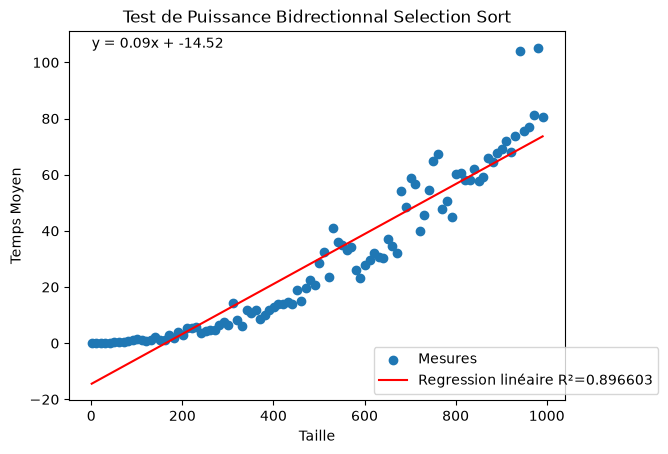

In [ ]:
data = {}
for m in bi_directional_measures:
  data[m.size] = m.mean
test_de_puissance(data=data, x_label='Taille', y_label='Temps Moyen', title="Test de Puissance Bidrectionnal Selection Sort")

<u>**Question 2.b):**</u> Analysez le graphe obtenu pour le test de puissance.

#### Test de rapport

<u>**Question 3.a):**</u> Effectuez le test de rapport de votre algorithme.

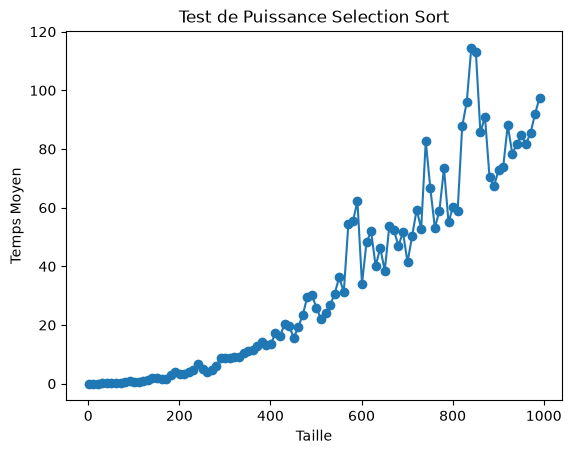

In [ ]:
data = {}
for m in selection_sort_measures:
  data[m.size] = m.mean
test_de_rapport(data=data, x_label='Taille', y_label='Temps Moyen', title="Test de Puissance Selection Sort")

<u>**Question 3.b):**</u> Analysez le graphe obtenu pour le test de rapport.

#### Test des constantes

<u>**Question 4.a):**</u> Effectuez le test des constantes de votre algorithme.

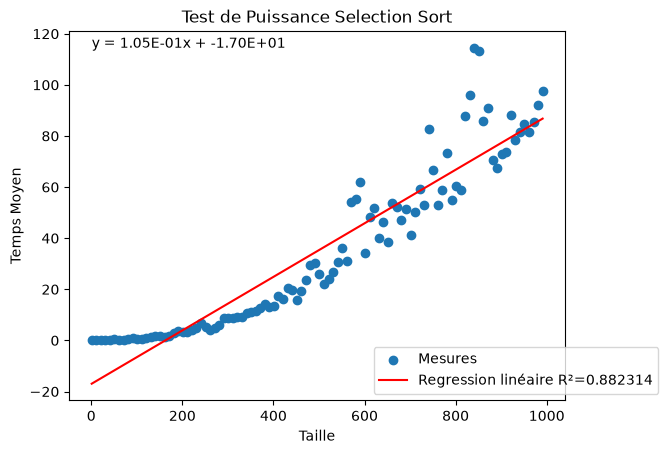

In [ ]:
data = {}
for m in selection_sort_measures:
  data[m.size] = m.mean
test_de_constantes(data=data, x_label='Taille', y_label='Temps Moyen', title="Test de Puissance Selection Sort")

<u>**Question 4.b):**</u> Analysez le graphe obtenu pour le test des constantes.

## Partie 3 : Algorithme diviser pour régner (Quick Sort) (9 pts)

### Implantation

<u>**Question 1.a):**</u> Implantez l'algorithme de tri quick sort et les deux stratégies de sélection de pivot. Cette algorithme utilise le patron de conception "Diviser pour régner".

Utilisez la fonction `is_valid_solution` pour valider votre réponse sur quelques exemplaires aléatoires.

In [ ]:
def quick_sort(original: list[int], pivot_fn: Callable[[list[int], int, int], int]) -> list[int]:
    # TODO
    return original

# Vous pouvez modifier la signature des fonctions pivots si vous voulez

def first_element_pivot(elements: list[int], left: int, right: int) -> int:
    # TODO
    pass

def random_element_pivot(elements: list[int], left: int, right: int) -> int:
    # TODO
    pass

# Utilisez ces fonctions pour spécifier la stratégie de sélection de pivot

def quick_sort_first(original: list[int]) -> list[int]:
    return quick_sort(original, first_element_pivot)

def quick_sort_random(original: list[int]) -> list[int]:
    return quick_sort(original, random_element_pivot)

<u>**Question 1.b):**</u> Quelle est la complexité asymptotique théorique de cet algorithme? Veuillez justifier.

### Mesures

Pour l'algorithme de tri quick sort, vous devez effectuer des mesures à la fois sur des exemplaires aléatoires et des exemplaires triés.

Vous pouvez spécifier la distribution d'exemplaires souhaitée avec le paramètre `distribution` de `make_problems`.

<u>**Question 1.c):**</u> Faites afficher vos mesures dans un tableau avec la fonction `display_data_as_table`.

In [ ]:
# TODO take measurements

In [ ]:
# TODO Display data as tables

### Analyse Hybride

#### Test de puissance

<u>**Question 2.a):**</u> Effectuez le test de puissance de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test de puissance de quick_sort_first

<u>**Question 2.b):**</u> Analysez les graphes obtenus pour le test de puissance.

<u>**Question 2.c):**</u> Effectuez le test de puissance de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test de puissance de quick_sort_random

<u>**Question 2.d):**</u> Analysez les graphes obtenus pour le test de puissance.

#### Test de rapport

<u>**Question 3.a):**</u> Effectuez le test de rapport de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test de rapport de quick_sort_first

<u>**Question 3.b):**</u> Analysez le graphe obtenu pour le test de rapport.

<u>**Question 3.c):**</u> Effectuez le test de rapport de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test de rapport de quick_sort_random

<u>**Question 3.d):**</u> Analysez les graphes obtenus pour le test de puissance.

#### Test des constantes

<u>**Question 4.a):**</u> Effectuez le test des constantes de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test des constantes de quick_sort_first

<u>**Question 4.b):**</u> Analysez le graphe obtenu pour le test des constantes.

<u>**Question 4.c):**</u> Effectuez le test des constantes de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test des constantes de quick_sort_random

<u>**Question 4.d):**</u> Analysez le graphe obtenu pour le test des constantes.

## Partie 4 : Algorithme diviser pour régner avec seuil de récursivité (Quick Sort) (6 pts)

### Implantation

<u>**Question 1.a):**</u> Quel serait un meilleur choix de seuil? Utilisez la fonction `estimate_threshold` pour avoir une idée où commencer.

Vous devez trouver un seuil par stratégie de sélection de pivot. Analysez les graphes résultants et choisissez des seuils de départ.

On recommande de compiler des nouvelles données sur des tailles plus petites. Utilisez un `time_scale` plus grand pour avoir plus de détails (indiquez les unités dans le `y_label`). Une fois que vous avez une idée d'où se situe le point de croisement, vous pouvez refaire le test sur une sélection plus restreinte de tailles en augmentant `num_samples` pour avoir des résultats plus constants.

In [ ]:
# TODO Find a better starting points for the thresholds

<u>**Question 1.b):**</u> Reprenez l'algorithme précédent et modifiez-le pour y ajouter un seuil de récursivité. En dessous de ce seuil, vous utiliserez l'algorithme `bidirectional_selection_sort` écrit précédemment.

Utilisez la fonction `is_valid_solution` pour valider votre réponse sur quelques exemplaires aléatoires.

In [ ]:
def quick_sort_threshold(original: list[int], pivot_fn: Callable[[list[int], int, int], int], threshold: int) -> list[int]:
    # TODO
    return original

# Utilisez ces fonctions pour spécifier la stratégie de sélection de pivot

def quick_sort_threshold_first(original: list[int], threshold: int = 1) -> list[int]:
    return quick_sort_threshold(original, first_element_pivot, threshold)

def quick_sort_threshold_random(original: list[int], threshold: int = 1) -> list[int]:
    return quick_sort_threshold(original, random_element_pivot, threshold)

<u>**Question 1.c):**</u> À l'aide de ce que vous avez vu dans la section précédente, effectuez les mesures avec plusieurs seuils de récursivité pour déterminer le seuil le plus judicieux. Affichez-les dans un graphique une fois que les mesures sont compilées. La fonction `test_threshold` vous sera utile pour faire ces tests. Choisissez bien vos seuils ainsi qu'une taille de liste permettant de bien observer la différence de performance.

In [ ]:
# TODO Test different threshold values

In [ ]:
# TODO Display a graph with the measurements

<u>**Question 1.d):**</u> Quel est le seuil de récursivité le plus judicieux pour chaque stratégie de sélection de pivot? Sur quel critère l'avez-vous sélectionné? Pourquoi des seuils inférieurs ou supérieurs donnent-ils de moins bonnes performances?

Changez le seuil par défaut de vos fonctions au meilleur choix. Ceci vous permettra d'utiliser les fonctions utilitaires sans passer le seuil comme argument.

<u>**Question 1.e):**</u> La complexité asymptotique théorique de cet algorithme a-t-elle changée? Veuillez justifier.

### Mesures

Pour l'algorithme de tri quick sort avec seuil de récursivité, vous devez effectuer des mesures à la fois sur des exemplaires aléatoires et des exemplaires triés.

<u>**Question 1.f):**</u> Faites afficher vos mesures dans un tableau avec la fonction `display_data_as_table`.

In [ ]:
# TODO take measurements

In [ ]:
# TODO Display data as tables

### Analyse Hybride

#### Test de puissance

<u>**Question 2.a):**</u> Effectuez le test de puissance de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test de puissance de quick_sort_threshold_first

<u>**Question 2.b):**</u> Analysez le graphe obtenu pour le test de puissance.

<u>**Question 2.c):**</u> Effectuez le test de puissance de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test de puissance de quick_sort_threshold_random

<u>**Question 2.d):**</u> Analysez les graphes obtenus pour le test de puissance.

#### Test de rapport

<u>**Question 3.a):**</u> Effectuez le test de rapport de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test de rapport de quick_sort_threshold_first

<u>**Question 3.b):**</u> Analysez le graphe obtenu pour le test de rapport.

<u>**Question 3.c):**</u> Effectuez le test de rapport de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test de rapport de quick_sort_threshold_random

<u>**Question 3.d):**</u> Analysez les graphes obtenus pour le test de puissance.

#### Test des constantes

<u>**Question 4.a):**</u> Effectuez le test des constantes de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test des constantes de quick_sort_threshold_first

<u>**Question 4.b):**</u> Analysez le graphe obtenu pour le test des constantes.

<u>**Question 4.c):**</u> Effectuez le test des constantes de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

In [ ]:
# TODO Test des constantes de quick_sort_threshold_random

<u>**Question 4.d):**</u> Analysez le graphe obtenu pour le test des constantes.

<u>**Question 5):**</u> Commentez l'impact du seuil de récursivité. Que représente-t-il pour l'algorithme diviser pour régner et l'algorithme naïf ?

# Conclusion (3 pts)

Résumez brièvement les principales observations issues de vos analyses et indiquez dans quelles situations chacun des algorithmes étudiés serait le plus approprié. Justifiez vos conclusions à l’aide des résultats obtenus.


 ## Autres critères (2 pts)
 Qualité du code / 1 pt

Présentation générale / 1 pt

- Concision
- Qualité du français

Pénalité retard
- -2 pt / journée de retard, arrondi vers le haut. Les TPs ne sont plus acceptés après 3 jours.